In [1]:
%matplotlib inline

# Chemical Reactions

Since version 4, CADET supports modeling chemical reactions using mass action law (see [Reaction models](https://cadet.github.io/master/modelling/reactions.html#reaction-models)).

The mass action law states that the reaction rate is proportional to the product of the reactant concentrations.

In CADET-Process, a reaction module simplifies the setup of these reactions.
Two classes are available: `MassActionLaw` for bulk phase reactions and `MassActionLawParticle` for particle pore phase reactions.

In this tutorial, you will learn to set up:
- Forward reactions
- Equilibrium reactions

```{warning}
We are in the process of completely overhauling the reactions system in CADET.
This includes:
- New reaction models (e.g., pH, Michaelis-Menten, cell growth),
- Multiple simulataneous reactions,
- Reactions in rapid equilibrium.

However, this also means, breaking changes will occur in the near future for this module.
```

## Forward Reactions
As a simple example, consider the following system:

$$
1\,\mathrm{A} \xrightarrow{k_{AB}} 1\,\mathrm{B}
$$

First, create a `ComponentSystem` with components `A` and `B`.

In [2]:
from CADETProcess.processModel import ComponentSystem
component_system = ComponentSystem(['A', 'B'])

Next, configure the `MassActionLaw` reaction model.
Instantiate it by passing the `ComponentSystem`.
Add the reaction using the `add_reaction` method with these arguments:
- `indices`: Indices of the components involved in the reaction
- `coefficients`: Stoichiometric coefficients in the order of the indices
- `k_fwd`: Forward reaction rate
- `k_bwd`: Backward reaction rate

In [3]:
from CADETProcess.processModel import MassActionLaw
reaction_system = MassActionLaw(component_system)
reaction_system.add_reaction(
    indices=[0,1],
    coefficients=[-1, 1],
    k_fwd=0.1,
    k_bwd=0
)

To demonstrate this reaction, create a `Cstr` and add the reaction to it.
Set the initial conditions.
The `Cstr` supports reactions in bulk and particle pore phases.
Since the porosity is $1$ by default, only the bulk phase is considered.

In [4]:
from CADETProcess.processModel import Cstr

reactor = Cstr(component_system, 'reactor')
reactor.bulk_reaction_model = reaction_system
reactor.init_liquid_volume = 1e-6
reactor.const_solid_volume = 0
reactor.c = [1.0, 0.0]

Add the reactor to a `FlowSheet` and set up a `Process`.
Here, the `FlowSheet` contains only the `Cstr`, and there are no `Events` in the process.

In [5]:
from CADETProcess.processModel import FlowSheet
flow_sheet = FlowSheet(component_system)
flow_sheet.add_unit(reactor)

from CADETProcess.processModel import Process
process = Process(flow_sheet, 'reaction_demo')
process.cycle_time = 100

After simulation, plot the results:

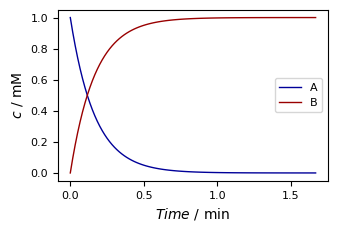

In [6]:
from CADETProcess.simulator import Cadet
simulator = Cadet()
sim_results = simulator.simulate(process)
_ = sim_results.solution.reactor.outlet.plot()

## Equilibrium Reactions
Equilibrium reactions allow the product to revert to the reactants:

$$
2\,\mathrm{A} \xleftrightarrow[k_{BA}]{k_{AB}} \mathrm{B}
$$

Reuse the same units, flow sheet, and process defined above.

In [7]:
reaction_system = MassActionLaw(component_system)
reaction_system.add_reaction(
    indices=[0,1],
    coefficients=[-2, 1],
    k_fwd=0.2,
    k_bwd=0.1
)

reactor.bulk_reaction_model = reaction_system

After simulation, plot the results:

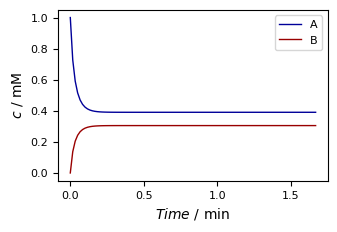

In [8]:
sim_results = simulator.simulate(process)
_ = sim_results.solution.reactor.outlet.plot()